In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split


import yaml
#from sklearn import train_test_split

import sys

sys.path.append("../src")
import functions as fn


#import dataset
with open("../config.yaml") as file:
    config = yaml.safe_load(file)
config


{'input_data': {'file1': '../data/raw/diabetes_prediction_dataset.csv',
  'file3': None},
 'output_data': {'file1': None}}

In [4]:
df = pd.read_csv(config['input_data']['file1'], delimiter = ",")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [91]:
##############################################################################
# Cleaning Dataset
##############################################################################

def clean_dataset(df):
    """
    Drops duuplicated rows: 3854 in total
    """
    df1 = df.copy()
    df1 = df1.drop_duplicates(keep = 'first')
    df1 = df1.reset_index(drop = True)

    return df1


In [92]:
df = clean_dataset(df)
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
96141,Female,36.0,0,0,No Info,24.60,4.8,145,0
96142,Female,2.0,0,0,No Info,17.37,6.5,100,0
96143,Male,66.0,0,0,former,27.83,5.7,155,0
96144,Female,24.0,0,0,never,35.42,4.0,100,0
96145,Female,57.0,0,0,current,22.43,6.6,90,0


In [59]:
df.smoking_history.unique()
#
#relationship beween columns
#sns.pairplot(df, hue = 'diabetes')

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

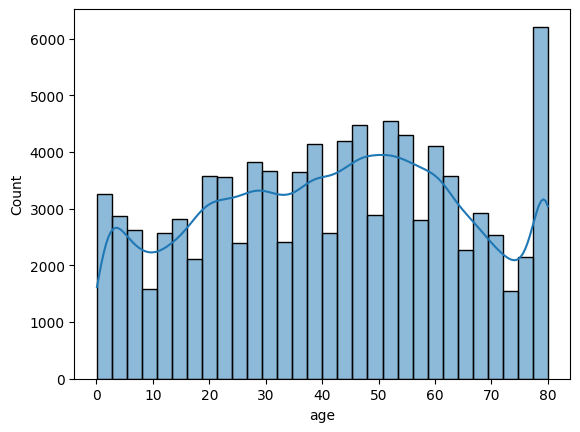

In [38]:
#Understand the sitribution of data
#Age distribution 
sns.histplot(data = df1, x = 'age', bins = 30, kde = True)
plt.show()

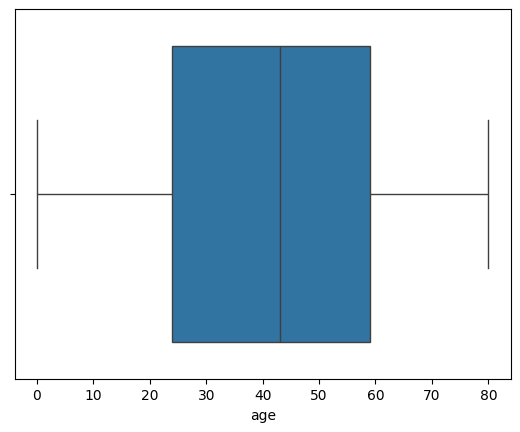

In [42]:
# Average age of patients


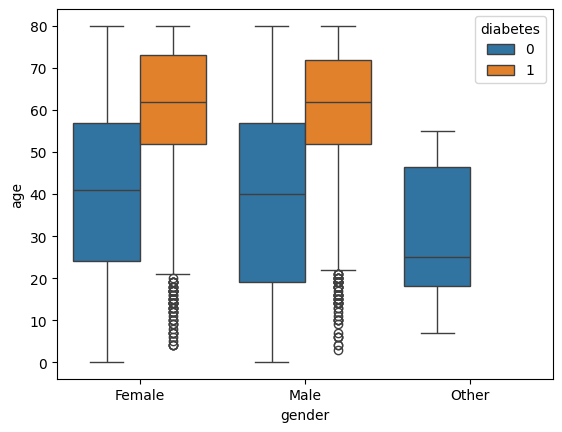

In [43]:
#AGE vs sex
sns.boxplot(data = df1, x = 'gender', y = 'age', hue = 'diabetes')
plt.show()

# Dataset description:
Dataset is mainly cleaned, with redundant values. We dropped them to have consistent database. It consists of three columns categories:
### 1. Normalized data:
#### a. Already normalized:
Hypertension & heart_disease: both of them have binary values, 1 for "Yes", and 0 for "No". No further processing is needed.
#### b. Ordinal categorical columns:
smoking_history: ['never', 'No Info', 'current', 'former', 'ever', 'not current']. As there is no implicit order between them, we have chosen to consider them as nominal categorical data.
gender: femal, Male, Other: Ordinal categorical data 
#### c. Numerical:
age, bmi, HbA1c_level and blood_glucose_level: Ranges are quite big. Theses columns will be subject to scaling
# features Engineering:
## a. Encoding: OneHeadEncoding
OneHeadEncoding: used to encode the nominal categorical data "smoking_history"
## b. Normalization: 
Use MinMaxScaler() to normalize numerical data
# Predictive Model and Features engineering:
## a. KNN Model:
Our target data is clategorical, for this we have chosen KNN model

In [94]:
##############################################################################
# Dataset train_test_split
##############################################################################
def data_set_splitter(df):
    df1 = df.copy()
    features = df1.drop(columns = 'diabetes')
    target = df1['diabetes']
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size = 0.2, random_state = 40)
    return X_train, X_test, y_train, y_test
dX_train, X_test, y_train, y_test = data_set_splitter(df)
dX_train.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
36502,Female,39.0,1,0,never,27.91,5.8,300
31611,Male,24.0,0,0,No Info,45.96,3.5,158
44120,Male,80.0,0,0,not current,27.32,6.5,90
46040,Male,6.0,0,0,No Info,14.84,6.6,145
87556,Female,54.0,0,0,never,23.77,4.5,100


In [95]:
# Features dummification: Encoding gender & smoking_history columns
#df1 = clean_dataset(df)
def get_ohe_encoded_col(df):
    """
    Features dummification: Encoding gender & smoking_history columns
    """
    df1 = df.copy()
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
   
    X_train_cat = X_train.select_dtypes('object')
    X_test_cat = X_test.select_dtypes('object')
    #create a OneHotENcoder class instance
    ohe = OneHotEncoder(sparse_output = False, drop = 'first')
    #determine unique values of each column
    ohe.fit(X_train_cat)
    #ohe.fit(X_test_cat) # NOOO fit only train data
    #Output np array
    X_train_np = ohe.transform(X_train_cat)
    X_test_np = ohe.transform(X_test_cat)
    #tranfsorm the np aaray to df
    X_train_ohe_df = pd.DataFrame(X_train_np, columns = ohe.get_feature_names_out(), index = X_train_cat.index)
    X_test_ohe_df= pd.DataFrame(X_test_np, columns = ohe.get_feature_names_out(), index = X_test_cat.index)
    

    return X_train_ohe_df, X_test_ohe_df
    

X_train_ohe_df, X_test_ohe_df = get_ohe_encoded_col(df) #X_train_ohe_df, X_test_ohe_df, 

X_train_ohe_df.head()

,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
36502,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31611,1.0,0.0,0.0,0.0,0.0,0.0,0.0
44120,1.0,0.0,0.0,0.0,0.0,0.0,1.0
46040,1.0,0.0,0.0,0.0,0.0,0.0,0.0
87556,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [96]:
# Scaling: Normalization of numerical data
#TO REDO SPLIT DATSET BEFORE NORMLIZATION
def get_normalized_col(df):

    df1 = df.copy()
    #train_test_split
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
    X_train_num = X_train[['age', 'bmi','HbA1c_level', 'blood_glucose_level']]
    X_test_num = X_test[['age', 'bmi','HbA1c_level', 'blood_glucose_level']]

    #Create the scaler
    normalizer = MinMaxScaler()
    #determine Mi max of every colum
    normalizer.fit(X_train_num)
    #normalizer.fit(X_test_num) #NOO

    #transform data to np array
    X_train_num_np = normalizer.transform(X_train_num)
    X_test_num_np = normalizer.transform(X_test_num)
    
    #transfor np arrays to df
    X_train_normalized = pd.DataFrame(
                                        X_train_num_np,
                                        columns = X_train_num.columns, 
                                        index = X_train_num.index
                                    )
    X_test_normalized = pd.DataFrame(
                                        X_test_num_np,
                                        columns = X_test_num.columns,
                                        index = X_test_num.index
                                    )
    return X_train_normalized, X_test_normalized #, y_train, y_test#, combined_norm_df
X_train_normalized, X_test_normalized =get_normalized_col(df)
X_train_normalized.head()

,age,bmi,HbA1c_level,blood_glucose_level
36502,0.486987,0.210069,0.418182,1.000000
31611,0.299299,0.421899,0.000000,0.354545
44120,1.000000,0.203145,0.545455,0.045455
46040,0.074074,0.056683,0.563636,0.295455
87556,0.674675,0.161483,0.181818,0.090909


In [99]:
# Get the non processed df
def get_non_process_df(df):
    
    df1 = df.copy()
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
    
    X_train_others = X_train[['hypertension', 'heart_disease']]
    X_test_others = X_test[['hypertension', 'heart_disease']]

    return X_train_others, X_test_others #, y_train, y_test
     
X_train_others,  X_test_others =  get_non_process_df(df)


def return_combined_train_test_split_df(df):

    #call Xtrain and Xtest from corresponding functions
    X_train_others,  X_test_others =  get_non_process_df(df)
    #y_train_others,  y_test_others =  get_non_process_df(df)[2:4]
    
    X_train_normalized, X_test_normalized = get_normalized_col(df)
    #y_train_normalized, y_test_normalized = get_normalized_col(df)[2:4]
    
    X_train_ohe_df, X_test_ohe_df = get_ohe_encoded_col(df)
    #y_train_ohe_df, y_test_ohe_df = get_ohe_encoded_col(df)[2:4]
   
    #concatenate df
    X_train_final = pd.concat([X_train_ohe_df, X_train_normalized, X_train_others], axis = 1)
    X_test_final = pd.concat([X_test_ohe_df, X_test_normalized, X_test_others], axis = 1)
    #y_train_final = pd.concat([y_train_ohe_df, y_train_normalized, y_train_others], axis = 1)
    #y_test_final = pd.concat([y_test_ohe_df, y_test_normalized, y_test_others], axis = 1)

    return X_train_final, X_test_final

X_train_final, X_test_final = return_comobined_train_test_split_df(df)
display(X_train_others.head())
display(X_train_final.head())

,hypertension,heart_disease
36502,1,0
31611,0,0
44120,0,0
46040,0,0
87556,0,0


,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease
36502,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.486987,0.210069,0.418182,1.000000,1,0
31611,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.299299,0.421899,0.000000,0.354545,0,0
44120,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.203145,0.545455,0.045455,0,0
46040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.074074,0.056683,0.563636,0.295455,0,0
87556,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.674675,0.161483,0.181818,0.090909,0,0


In [103]:
##############################################################################
# Train the KNN model
##############################################################################
import time
start = time.time()
X_train_final, X_test_final = return_combined_train_test_split_df(df)
y_train_final, y_test_final = data_set_splitter(df)[2:4]

print("Preprocessing:", time.time() - start)

start = time.time()
#Create class instance of KNN predective model
knn = KNeighborsClassifier(n_neighbors =10, n_jobs=-1)

#train the model
knn.fit(X_train_final, y_train_final)
print("Fit:", time.time() - start)

#Make predictions
start = time.time()
pred_train = knn.predict(X_train_final)
pred_test= knn.predict(X_test_final)
print("Predict:", time.time() - start)

#Evaluate model
start = time.time()
print(f"Accuracy of the model on Train dataset is: {knn.score(X_train_final, y_train_final)*100: .2f}% ")
print(f"Accuracy of the model on Test dataset is: { knn.score(X_test_final, y_test_final)*100: .2f}%")
print("Score calculation:", time.time() - start)

Preprocessing: 0.30780982971191406
Fit: 0.4082975387573242
Predict: 66.85446095466614
Accuracy of the model on Train dataset is:  96.31% 
Accuracy of the model on Test dataset is:  96.04%
Score calculation: 66.65434432029724
